# 1. Load German Credit dataset

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,make_scorer

path = "./data/german.data"

columns = [
    "status", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment", "installment_rate", "personal_status_sex",
    "other_debtors", "residence_since", "property", "age",
    "other_installment_plans", "housing", "existing_credits",
    "job", "liable_maintenance_people", "telephone", "foreign_worker",
    "target"
]

df = pd.read_csv(path, sep=r'\s+', names=columns)

X = df.drop("target", axis=1)
y = df["target"].map({1: 1, 2: 0}) # 1 = good , 0 = bad

# 2. Preprocessing: One-Hot for categoricals

In [2]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

C:\Users\USER\AppData\Local\Temp\ipykernel_6116\2045447223.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


# 3. Cost function

In [3]:
def cost_scorer(estimator, X_valid, y_valid, fp_cost=5, fn_cost=1):
    """
    Scorer for GridSearchCV.
    - Uses estimator.predict(X_valid) (threshold 0.5)
    - Computes cost = 5*FP + 1*FN
    - Returns NEGATIVE cost (because GridSearchCV always maximizes the score)
    """
    proba_test = estimator.predict_proba(X_valid)[:, 1]
    y_pred = (proba_test >= 0.5).astype(int)

    # Always 2x2 confusion matrix, even if one class missing in a fold
    cm = confusion_matrix(y_valid, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cost = fp_cost * fp + fn_cost * fn
    return -float(cost)   # higher (less negative) = better (lower cost)

# 4. Pipeline

In [4]:
clf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("clf", clf),
])

param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [6, 10, None],
    "clf__min_samples_split": [2, 4, 8],
     "clf__min_samples_leaf": [1, 2, 4],
    # class 0 = BAD (more important), class 1 = GOOD
    "clf__class_weight": [
        None,
        {0: 5, 1: 1},
        {0: 8, 1: 1},
        "balanced"
    ],
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=cost_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train)

print("Best params from GridSearchCV:")
print(grid.best_params_)
print("Best (negative) cost score in CV:", grid.best_score_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params from GridSearchCV:
{'clf__class_weight': {0: 5, 1: 1}, 'clf__max_depth': 6, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 8, 'clf__n_estimators': 200}
Best (negative) cost score in CV: -82.8


# 5. Find best Threshold

In [5]:
def compute_cost(y_true, y_pred, fp_cost=5, fn_cost=1):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return fp_cost * fp + fn_cost * fn, (tn, fp, fn, tp)
# ==========================================================
def find_best_threshold(y_true, proba_good, fp_cost=5, fn_cost=1, n_steps=501):
    thresholds = np.linspace(0, 1, n_steps)
    best_thr = 0.5
    best_cost = np.inf

    for thr in thresholds:
        y_pred = (proba_good >= thr).astype(int)
        cost, _ = compute_cost(y_true, y_pred, fp_cost, fn_cost)
        if cost < best_cost:
            best_cost = cost
            best_thr = thr
    return best_thr, best_cost



proba_good_test = best_model.predict_proba(X_test)[:, 1]
best_thr, best_val_cost = find_best_threshold(
    y_test,
    proba_good_test,
    fp_cost=5,
    fn_cost=1
)
y_pred_test = (proba_good_test >= best_thr).astype(int)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()
cost = 5 * fp + 1 * fn

print("\nConfusion matrix on TEST set:")
print(cm)
print(f"\nFP (bad→good): {fp} | FN (good→bad): {fn}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))
print(f"Total cost (5*FP + 1*FN): {cost}")
print(f"Threshold used: {best_thr:.3f}")


Confusion matrix on TEST set:
[[55  5]
 [64 76]]

FP (bad→good): 5 | FN (good→bad): 64
Accuracy: 0.6550
              precision    recall  f1-score   support

           0       0.46      0.92      0.61        60
           1       0.94      0.54      0.69       140

    accuracy                           0.66       200
   macro avg       0.70      0.73      0.65       200
weighted avg       0.80      0.66      0.67       200

Total cost (5*FP + 1*FN): 89
Threshold used: 0.478


# 6. Save model

In [6]:
import joblib

model_path="./models/german_credit_rf.joblib"

metadata = {
        "categorical_cols": categorical_cols,
        "numeric_cols": numeric_cols,
        "feature_order": list(X.columns),
    }

obj_to_save = {
    "model": best_model,
    "metadata": metadata
}

joblib.dump(obj_to_save, model_path)
print(f"\nSaved best model to {model_path}")


Saved best model to ./models/german_credit_rf.joblib


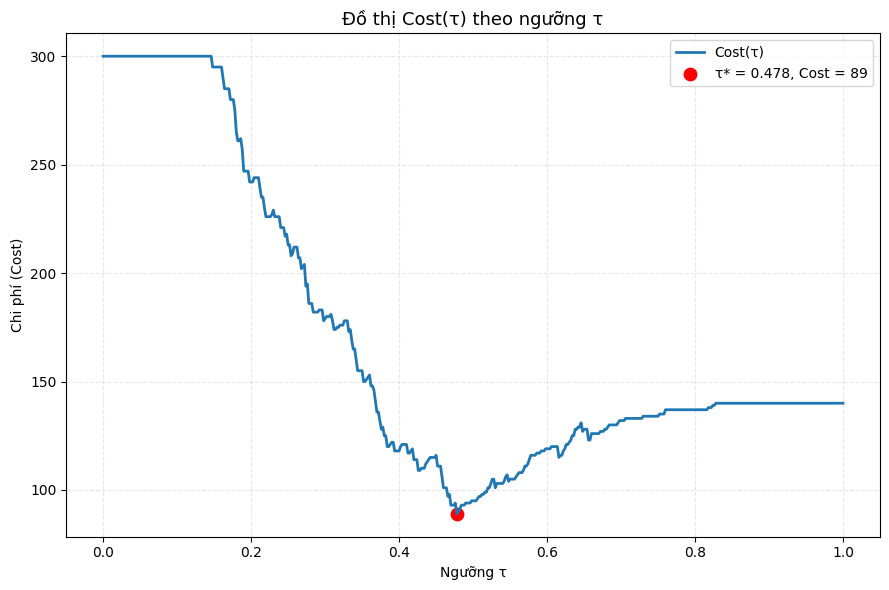

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ==========================================================
#  Tính τ* và cost tối ưu
# ==========================================================
best_thr, best_val_cost = find_best_threshold(
    y_test,
    proba_good_test,
    fp_cost=5,
    fn_cost=1
)

# ==========================================================
#  Chuẩn bị dữ liệu vẽ Cost(τ)
# ==========================================================
taus = np.linspace(0, 1, 501)
costs = []

for tau in taus:
    y_pred_tau = (proba_good_test >= tau).astype(int)
    cost_tau, _ = compute_cost(y_test, y_pred_tau, fp_cost=5, fn_cost=1)
    costs.append(cost_tau)

costs = np.array(costs)

# ==========================================================
#  Vẽ Hình 3.6
# ==========================================================
plt.figure(figsize=(9, 6))

plt.plot(taus, costs, linewidth=2, label="Cost(τ)")
plt.scatter([best_thr], [best_val_cost], color='red', s=80,
            label=f"τ* = {best_thr:.3f}, Cost = {best_val_cost:.0f}")

plt.title("Đồ thị Cost(τ) theo ngưỡng τ", fontsize=13)
plt.xlabel("Ngưỡng τ")
plt.ylabel("Chi phí (Cost)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [8]:
def generate_cost_table(y_true, proba_good, fp_cost=5, fn_cost=1, n_steps=11):
    """
    n_steps = số lượng ngưỡng τ muốn xem.
    Ví dụ: n_steps=21 => τ từ 0.00 đến 1.00 cách nhau 0.05.
    """
    thresholds = np.linspace(0, 1, n_steps)

    rows = []
    for tau in thresholds:
        y_pred = (proba_good >= tau).astype(int)
        cost, (tn, fp, fn, tp) = compute_cost(y_true, y_pred,
                                              fp_cost=fp_cost,
                                              fn_cost=fn_cost)
        rows.append({
            "tau": round(tau, 3),
            "FP": fp,
            "FN": fn,
            "Cost": cost
        })

    df = pd.DataFrame(rows)
    return df

# =================================================================
#  Tạo bảng 3.6
# =================================================================
df_cost_table = generate_cost_table(
    y_test,
    proba_good_test,
    fp_cost=5,
    fn_cost=1,
    n_steps=11  # 21 mức ngưỡng: 0.00, 0.05, 0.10, ..., 1.00
)

print(df_cost_table)

    tau  FP   FN  Cost
0   0.0  60    0   300
1   0.1  60    0   300
2   0.2  48    2   242
3   0.3  31   24   179
4   0.4  14   48   118
5   0.5   5   70    95
6   0.6   3  104   119
7   0.7   0  132   132
8   0.8   0  137   137
9   0.9   0  140   140
10  1.0   0  140   140


confusion matrix [[55  5]
 [64 76]]


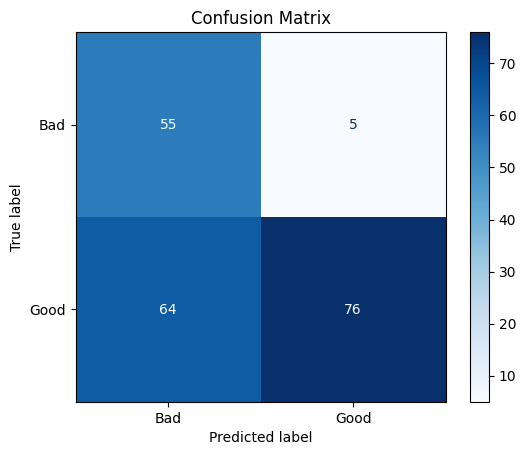

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Tạo confusion matrix
labels = ["Bad", "Good"]
print("confusion matrix", cm)

import matplotlib.pyplot as plt
# Hiển thị ma trận nhầm lẫn
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


# Raw Random Forrest

In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,make_scorer

# ==========================================================
# 1. Load German Credit dataset
# ==========================================================
url = "./data/german.data"

columns = [
    "status", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment", "installment_rate", "personal_status_sex",
    "other_debtors", "residence_since", "property", "age",
    "other_installment_plans", "housing", "existing_credits",
    "job", "liable_maintenance_people", "telephone", "foreign_worker",
    "target"
]

df = pd.read_csv(url, sep=r'\s+', names=columns)

X = df.drop("target", axis=1)

# 1 = good, 0 = bad
y = df["target"].map({1: 1, 2: 0})

# ==========================================================
# 2. Preprocessing: One-Hot for categoricals
# ==========================================================
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

# ==========================================================
# 3. Cost function: 5 * FP + 1 * FN (FP = bad→good, FN = good→bad)
#    Used DIRECTLY in GridSearchCV (no manual filtering of y_pred)
# ==========================================================
def cost_scorer(estimator, X_valid, y_valid, fp_cost=5, fn_cost=1):
    """
    Scorer for GridSearchCV.
    - Uses estimator.predict(X_valid) (threshold 0.5)
    - Computes cost = 5*FP + 1*FN
    - Returns NEGATIVE cost (because GridSearchCV always maximizes the score)
    """
    proba_test = estimator.predict_proba(X_valid)[:, 1]
    y_pred = (proba_test >= 0.5).astype(int)

    # Always 2x2 confusion matrix, even if one class missing in a fold
    cm = confusion_matrix(y_valid, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cost = fp_cost * fp + fn_cost * fn
    return -float(cost)   # higher (less negative) = better (lower cost)

# ==========================================================
# 4. Pipeline + cost-sensitive GridSearchCV (hyperparameter search)
# ==========================================================
clf = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200, max_depth=None, class_weight={0:5,1:1})

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("clf", clf),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

pipeline.fit(X_train, y_train)


# ==========================================================
# 5. Final evaluation on TEST set (same decision rule)
# ==========================================================
proba_good_test = pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (proba_good_test >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()
cost = 5 * fp + 1 * fn

print("\nConfusion matrix on TEST set:")
print(cm)
print(f"\nFP (bad→good): {fp} | FN (good→bad): {fn}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test))
print(f"Total cost (5*FP + 1*FN): {cost}")


C:\Users\USER\AppData\Local\Temp\ipykernel_6116\1535427215.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()



Confusion matrix on TEST set:
[[ 22  38]
 [ 13 127]]

FP (bad→good): 38 | FN (good→bad): 13
Accuracy: 0.7450
              precision    recall  f1-score   support

           0       0.63      0.37      0.46        60
           1       0.77      0.91      0.83       140

    accuracy                           0.74       200
   macro avg       0.70      0.64      0.65       200
weighted avg       0.73      0.74      0.72       200

Total cost (5*FP + 1*FN): 203
